### TASK:        

### Build a transfer learnt model from a model trained on EfficientNet by unfreezing some existing layers and then applying finetuning

### Import Necessary Libraries

In [103]:
import ssl
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.metrics import AUC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Scikit-learn imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, accuracy_score

# LIME and image segmentation
from lime import lime_image
from skimage.segmentation import mark_boundaries

### Load The Dataset

In [104]:
# Load Data
x = np.load('X.npy')
y = np.load('y.npy')

In [105]:
# Get value counts for y (class labels) as a pandas Series
value_counts = pd.Series(y).value_counts()
print("Class distribution:")
print(value_counts)

Class distribution:
food       10786
inside      5633
outside     1877
drink       1548
menu         156
Name: count, dtype: int64


### Data Split and Preprocessing

In [106]:
# Split data (without stratifying y_val)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

# Now, stratify only y_train while keeping the same size
x_train, _, y_train, _ = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [107]:
# Apply Label Encoding to the labels after splitting
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)

# Apply One-Hot Encoding
y_train = to_categorical(y_train, num_classes=5)  
y_val = to_categorical(y_val, num_classes=5)  

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=np.unique(np.argmax(y_train, axis=1)), 
                                    y=np.argmax(y_train, axis=1))
class_weights = dict(enumerate(class_weights))

# EfficientNet preprocessing (DO NOT divide by 255)
x_train = preprocess_input(x_train)  # Automatically scales to [-1,1]
x_val = preprocess_input(x_val)

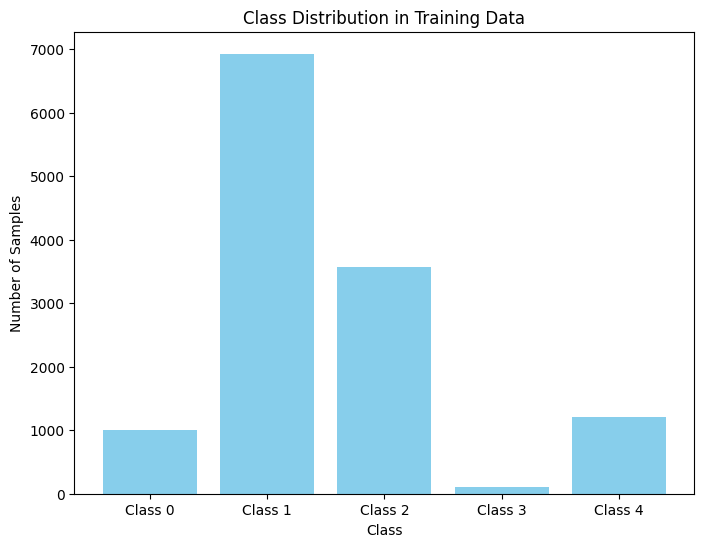

In [108]:
def plot_class_distribution(y_train):
    # Calculate the number of samples per class
    class_counts = np.sum(y_train, axis=0)
    
    # Plotting the class distribution
    plt.figure(figsize=(8, 6))
    plt.bar(range(len(class_counts)), class_counts, color='skyblue')
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.title('Class Distribution in Training Data')
    plt.xticks(range(len(class_counts)), [f'Class {i}' for i in range(len(class_counts))])
    plt.show()

# Example usage
plot_class_distribution(y_train)

### Model 1 - Model Building and Training (without data augumentation)

### Iteration 1 - Model 1

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import seaborn as sns
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC



# ----------------- ITERATION 1 - INITIAL TRAINING -----------------

# Load pretrained EfficientNet model without the top classification layers for Iteration 1
base_model_1 = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))

# Freeze base model layers for Iteration 1
base_model_1.trainable = False

# Functional API Model for Iteration 1
input_layer = layers.Input(shape=(64, 64, 3))
x = base_model_1(input_layer)  # EfficientNet base model

# Global Average Pooling layer
x = layers.GlobalAveragePooling2D()(x)

# Add a few more dense layers (with ReLU and Dropout for regularization)
x = layers.Dense(128, activation='relu')(x)  # Increased the size to 128
x = layers.Dropout(0.5)(x)  # Dropout for regularization

x = layers.Dense(64, activation='relu')(x)  # Additional dense layer
x = layers.Dropout(0.3)(x)  # Dropout for regularization

# Output layer with softmax activation for multi-class classification
output_layer = layers.Dense(5, activation='softmax')(x)

# Define the model using the functional API
model_1_iter1 = models.Model(inputs=input_layer, outputs=output_layer)

# Compile the model for Iteration 1
model_1_iter1.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Train the model for Iteration 1
history_1 = model_1_iter1.fit(x_train, y_train, validation_data=(x_val, y_val), class_weight=class_weights, epochs=20, batch_size=32)


Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.2104 - auc_15: 0.4846 - loss: 1.6690 - val_accuracy: 0.0747 - val_auc_15: 0.5000 - val_loss: 1.6189
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.2177 - auc_15: 0.5017 - loss: 1.6984 - val_accuracy: 0.0943 - val_auc_15: 0.5000 - val_loss: 1.5881
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.2435 - auc_15: 0.5049 - loss: 1.5943 - val_accuracy: 0.5315 - val_auc_15: 0.4997 - val_loss: 1.5903
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.2397 - auc_15: 0.4984 - loss: 1.6038 - val_accuracy: 0.0060 - val_auc_15: 0.5000 - val_loss: 1.6134
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.1693 - auc_15: 0.4897 - loss: 1.6156 - val_accuracy: 0.0940 - val_auc_15: 0.5000 - val_loss: 1.6129
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.1052 - auc_15: 0.4964 - loss: 1.6408 - val_accuracy: 0.0940 - val_auc_15: 0.5000 - val_loss:

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.0083 - auc_15: 0.4990 - loss: 1.6097
Train Accuracy (Iteration 1): 0.01
Train Loss (Iteration 1): 1.61
Train AUC (Iteration 1): 0.50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0087 - auc_15: 0.5000 - loss: 1.6097
Validation Accuracy (Iteration 1): 0.01
Validation Loss (Iteration 1): 1.61
Validation AUC (Iteration 1): 0.50


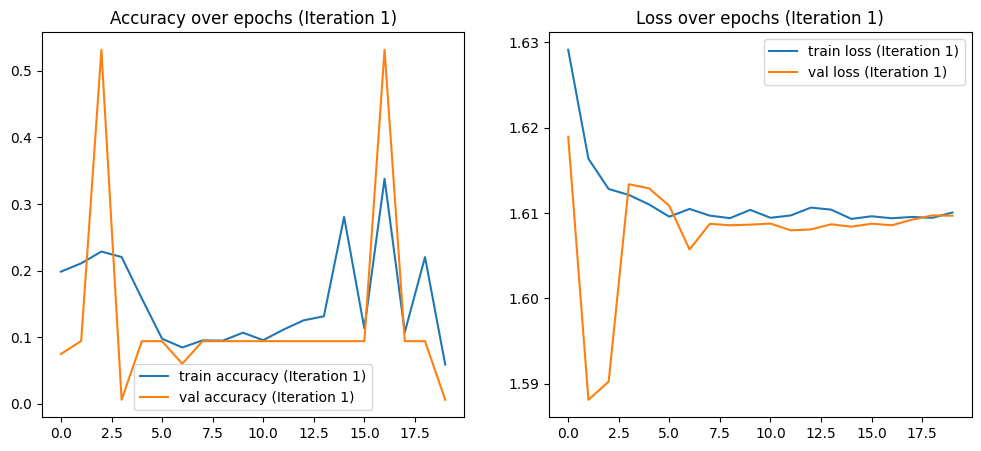

In [132]:
# ----------------- EVALUATE ITERATION 1 -----------------

# Evaluate on training data (Iteration 1)
train_loss_phase1, train_acc_phase1, train_auc_phase1 = model_1_iter1.evaluate(x_train, y_train)
print(f"Train Accuracy (Iteration 1): {train_acc_phase1:.2f}\nTrain Loss (Iteration 1): {train_loss_phase1:.2f}\nTrain AUC (Iteration 1): {train_auc_phase1:.2f}")

# Evaluate on validation data (Iteration 1)
val_loss_phase1, val_acc_phase1, val_auc_phase1 = model_1_iter1.evaluate(x_val, y_val)
print(f"Validation Accuracy (Iteration 1): {val_acc_phase1:.2f}\nValidation Loss (Iteration 1): {val_loss_phase1:.2f}\nValidation AUC (Iteration 1): {val_auc_phase1:.2f}")

# ----------------- PLOTTING TRAINING CURVES FOR ITERATION 1 -----------------

# Plot the training and validation accuracy and loss curves for Iteration 1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_1.history['accuracy'], label='train accuracy (Iteration 1)')
plt.plot(history_1.history['val_accuracy'], label='val accuracy (Iteration 1)')
plt.title('Accuracy over epochs (Iteration 1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_1.history['loss'], label='train loss (Iteration 1)')
plt.plot(history_1.history['val_loss'], label='val loss (Iteration 1)')
plt.title('Loss over epochs (Iteration 1)')
plt.legend()

plt.show()



Evaluation Metrics - Iteration 1:

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
Confusion Matrix:
[[   0    0    0  299    0]
 [   0    0    0 2126    0]
 [   0    0    0 1175    0]
 [   0    0    0   24    0]
 [   0    0    0  376    0]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00       299
     Class 1       0.00      0.00      0.00      2126
     Class 2       0.00      0.00      0.00      1175
     Class 3       0.01      1.00      0.01        24
     Class 4       0.00      0.00      0.00       376

    accuracy                           0.01      4000
   macro avg       0.00      0.20      0.00      4000
weighted avg       0.00      0.01      0.00      4000

Accuracy Score: 0.01
AUC Score: 0.49


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

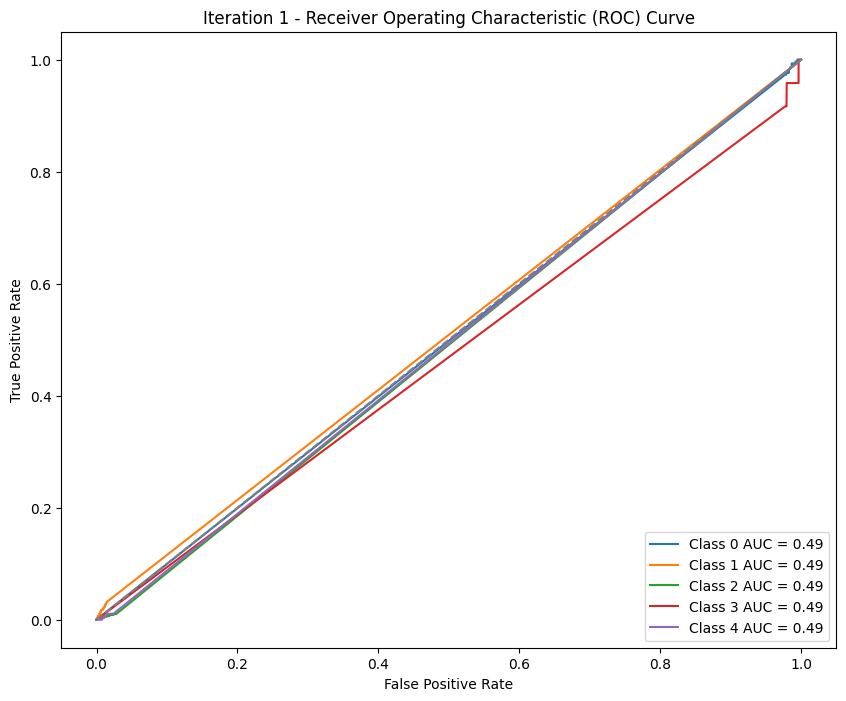

In [133]:
# Function to compute and print metrics
def evaluate_metrics(model, x_val, y_val, num_classes, iteration):
    print(f"Evaluation Metrics - Iteration {iteration}:\n")
    
    # Get model predictions for the current iteration
    y_pred = model.predict(x_val)  # Prediction (raw output)
    y_pred_prob = model.predict(x_val)  # Probabilities for AUC computation
    
    # Confusion Matrix
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report
    report = classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), target_names=[f'Class {i}' for i in range(num_classes)])
    print("\nClassification Report:")
    print(report)
    
    # Accuracy Score
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy Score: {accuracy:.2f}")
    
    # AUC Score (Multi-class)
    auc = roc_auc_score(y_val, y_pred_prob, multi_class='ovr')
    print(f"AUC Score: {auc:.2f}")
    
    # Plot AUC for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_val[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} AUC = {auc:.2f}')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f'Iteration {iteration} - Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

# Evaluate model for Iteration 1 (metrics and ROC)
evaluate_metrics(model_1_iter1, x_val, y_val, num_classes=5, iteration=1)

In [ ]:
# ----------------- ITERATION 2 - FINE-TUNING -----------------

# Unfreeze the last 30 layers for Iteration 2 (fine-tuning)
for layer in base_model_1.layers[-30:]:  # Unfreeze the last 30 layers
    layer.trainable = True

# Recompile the model after unfreezing layers
x = base_model_1(input_layer)  # EfficientNet base model
x = layers.GlobalAveragePooling2D()(x)

# Add the same dense layers as before (with Dropout)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output_layer = layers.Dense(5, activation='softmax')(x)

# Define the model using the functional API for Iteration 2
model_1_iter2 = models.Model(inputs=input_layer, outputs=output_layer)

# Recompile the model for Iteration 2 (fine-tuning)
model_1_iter2.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Train the model for Iteration 2 (fine-tuning)
history_2 = model_1_iter2.fit(x_train, y_train, validation_data=(x_val, y_val), class_weight=class_weights, epochs=20, batch_size=32)




In [ ]:
# ----------------- EVALUATE ITERATION 2 -----------------

# Evaluate on training data (Iteration 2)
train_loss_phase2, train_acc_phase2, train_auc_phase2 = model_1_iter2.evaluate(x_train, y_train)
print(f"Train Accuracy (Iteration 2): {train_acc_phase2:.2f}\nTrain Loss (Iteration 2): {train_loss_phase2:.2f}\nTrain AUC (Iteration 2): {train_auc_phase2:.2f}")

# Evaluate on validation data (Iteration 2)
val_loss_phase2, val_acc_phase2, val_auc_phase2 = model_1_iter2.evaluate(x_val, y_val)
print(f"Validation Accuracy (Iteration 2): {val_acc_phase2:.2f}\nValidation Loss (Iteration 2): {val_loss_phase2:.2f}\nValidation AUC (Iteration 2): {val_auc_phase2:.2f}")

# ----------------- PLOTTING TRAINING CURVES FOR ITERATION 2 -----------------

# Plot the training and validation accuracy and loss curves for Iteration 2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='train accuracy (Iteration 2)')
plt.plot(history_2.history['val_accuracy'], label='val accuracy (Iteration 2)')
plt.title('Accuracy over epochs (Iteration 2)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='train loss (Iteration 2)')
plt.plot(history_2.history['val_loss'], label='val loss (Iteration 2)')
plt.title('Loss over epochs (Iteration 2)')
plt.legend()

plt.show()


In [ ]:
# Function to compute and print metrics
def evaluate_metrics(model, x_val, y_val, num_classes, iteration):
    print(f"Evaluation Metrics - Iteration {iteration}:\n")
    
    # Get model predictions for the current iteration
    y_pred = model.predict(x_val)  # Prediction (raw output)
    y_pred_prob = model.predict(x_val)  # Probabilities for AUC computation
    
    # Confusion Matrix
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report
    report = classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), target_names=[f'Class {i}' for i in range(num_classes)])
    print("\nClassification Report:")
    print(report)
    
    # Accuracy Score
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy Score: {accuracy:.2f}")
    
    # AUC Score (Multi-class)
    auc = roc_auc_score(y_val, y_pred_prob, multi_class='ovr')
    print(f"AUC Score: {auc:.2f}")
    
    # Plot AUC for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_val[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} AUC = {auc:.2f}')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f'Iteration {iteration} - Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()


# Evaluate model for Iter
evaluate_metrics(model_1_iter2, x_val, y_val, num_classes=5, iteration=2)

In [126]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras.applications import EfficientNetB0
import matplotlib.pyplot as plt

# Load pre-trained EfficientNet model without top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model initially
base_model.trainable = False

# Input layer
input_layer = layers.Input(shape=(64, 64, 3))

# EfficientNet base model
x = base_model(input_layer)

# Global Average Pooling layer
x = layers.GlobalAveragePooling2D()(x)

# Add a few more dense layers (with ReLU and Dropout)
x = layers.Dense(128, activation='relu')(x)  # Increased the size to 128
x = layers.Dropout(0.5)(x)  # Dropout for regularization

x = layers.Dense(64, activation='relu')(x)  # Additional dense layer
x = layers.Dropout(0.3)(x)  # Dropout for regularization

# Output layer with softmax activation for multi-class classification
output_layer = layers.Dense(5, activation='softmax')(x)

# Define the model using the functional API
model_1 = models.Model(inputs=input_layer, outputs=output_layer)

# Compile the model (initial training with frozen base model layers)
model_1.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Model summary before training
model_1.summary()

# EarlyStopping callback to stop training if validation loss doesn't improve
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# ----------------- ITERATION 1: Train & Evaluate (Before Fine-Tuning) -----------------

# Train the model (Iteration 1)
history_phase1 = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    epochs=10,  # Train for initial epochs
    batch_size=32,
    callbacks=[early_stopping]
)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,120 (16.11 MB)

 Trainable params: 172,549 (674.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.2202 - auc_13: 0.4975 - loss: 1.5836 - val_accuracy: 0.0060 - val_auc_13: 0.5000 - val_loss: 1.6096
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.2061 - auc_13: 0.4816 - loss: 1.6473 - val_accuracy: 0.0747 - val_auc_13: 0.5000 - val_loss: 1.6180
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.1320 - auc_13: 0.4968 - loss: 1.6498 - val_accuracy: 0.0940 - val_auc_13: 0.4990 - val_loss: 1.5956
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.0870 - auc_13: 0.5043 - loss: 1.6112 - val_accuracy: 0.0938 - val_auc_13: 0.4779 - val_loss: 1.6097
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.0598 - auc_13: 0.4924 - loss: 1.5920 - val_accuracy: 0.2937 - val_auc_13: 0.5000 - val_loss: 1.6092
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.0483 - auc_13: 0.4919 - loss: 1.5912 - val_accuracy: 0.0940 - val_auc_13: 0.5000 - val_loss:

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.0973 - auc_13: 0.4951 - loss: 1.5960
Train Accuracy (Iteration 1): 0.09
Train Loss (Iteration 1): 1.60
Train AUC (Iteration 1): 0.50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1053 - auc_13: 0.4992 - loss: 1.5956
Validation Accuracy (Iteration 1): 0.09
Validation Loss (Iteration 1): 1.60
Validation AUC (Iteration 1): 0.50


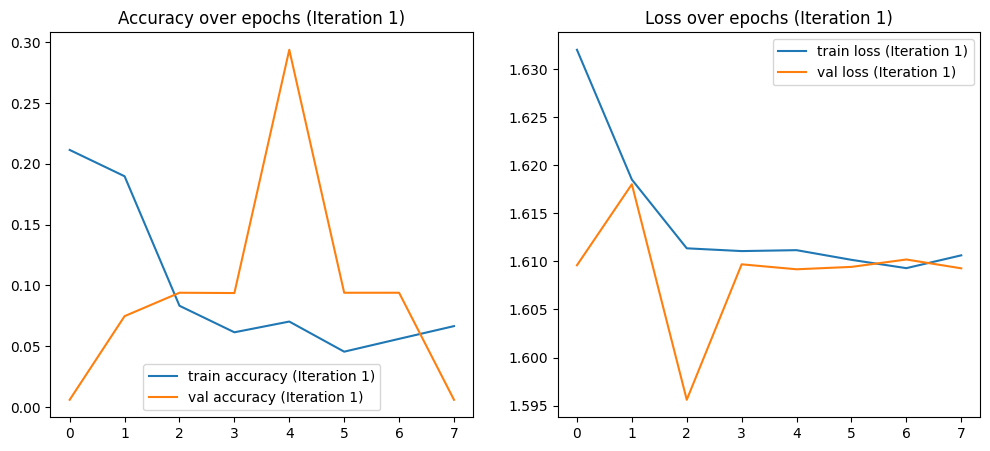

In [127]:
# ----------------- EVALUATE ITERATION 1 -----------------

# Evaluate on training data (Iteration 1)
train_loss_phase1, train_acc_phase1, train_auc_phase1 = model_1.evaluate(x_train, y_train)
print(f"Train Accuracy (Iteration 1): {train_acc_phase1:.2f}\nTrain Loss (Iteration 1): {train_loss_phase1:.2f}\nTrain AUC (Iteration 1): {train_auc_phase1:.2f}")

# Evaluate on validation data (Iteration 1)
val_loss_phase1, val_acc_phase1, val_auc_phase1 = model_1.evaluate(x_val, y_val)
print(f"Validation Accuracy (Iteration 1): {val_acc_phase1:.2f}\nValidation Loss (Iteration 1): {val_loss_phase1:.2f}\nValidation AUC (Iteration 1): {val_auc_phase1:.2f}")

# ----------------- PLOTTING TRAINING CURVES FOR ITERATION 1 -----------------

# Plot the training and validation accuracy and loss curves for Iteration 1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='train accuracy (Iteration 1)')
plt.plot(history_phase1.history['val_accuracy'], label='val accuracy (Iteration 1)')
plt.title('Accuracy over epochs (Iteration 1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'], label='train loss (Iteration 1)')
plt.plot(history_phase1.history['val_loss'], label='val loss (Iteration 1)')
plt.title('Loss over epochs (Iteration 1)')
plt.legend()

plt.show()



125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Evaluation Metrics - Iteration 1:

Confusion Matrix:
[[  19  280    0    0    0]
 [ 142 1984    0    0    0]
 [  52 1123    0    0    0]
 [   1   23    0    0    0]
 [  10  366    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.08      0.06      0.07       299
     Class 1       0.53      0.93      0.67      2126
     Class 2       0.00      0.00      0.00      1175
     Class 3       0.00      0.00      0.00        24
     Class 4       0.00      0.00      0.00       376

    accuracy                           0.50      4000
   macro avg       0.12      0.20      0.15      4000
weighted avg       0.29      0.50      0.36      4000

Accuracy Score: 0.50
AUC Score: 0.56


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

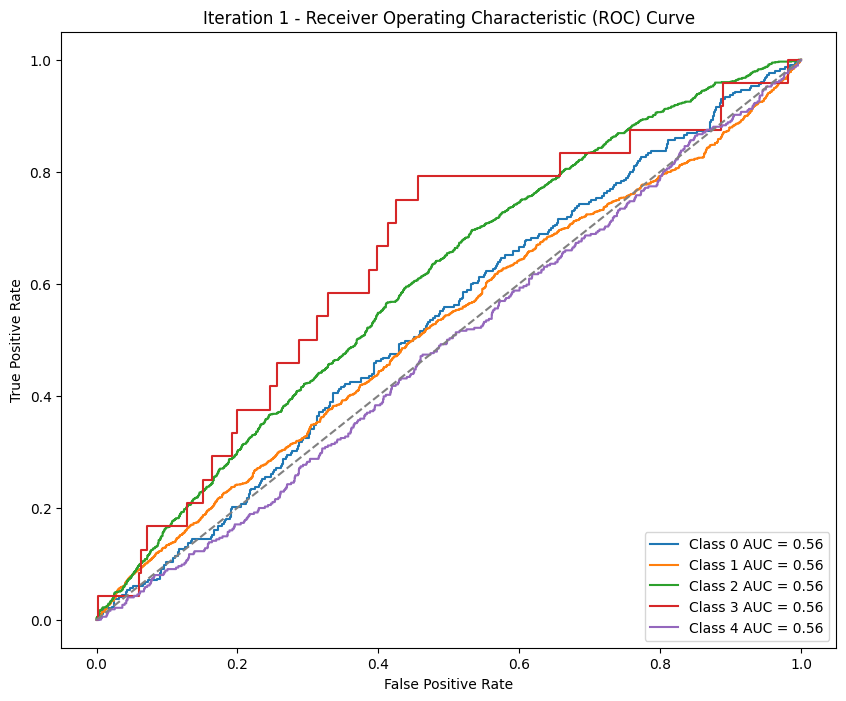

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Evaluation Metrics - Iteration 2:

Confusion Matrix:
[[  19  280    0    0    0]
 [ 142 1984    0    0    0]
 [  52 1123    0    0    0]
 [   1   23    0    0    0]
 [  10  366    0    0    0]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.08      0.06      0.07       299
     Class 1       0.53      0.93      0.67      2126
     Class 2       0.00      0.00      0.00      1175
     Class 3       0.00      0.00      0.00        24
     Class 4       0.00      0.00      0.00       376

    accuracy                           0.50      4000
   macro avg       0.12      0.20      0.15      4000
weighted avg       0.29      0.50      0.36      4000

Accuracy Score: 0.50
AUC Score: 0.56


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

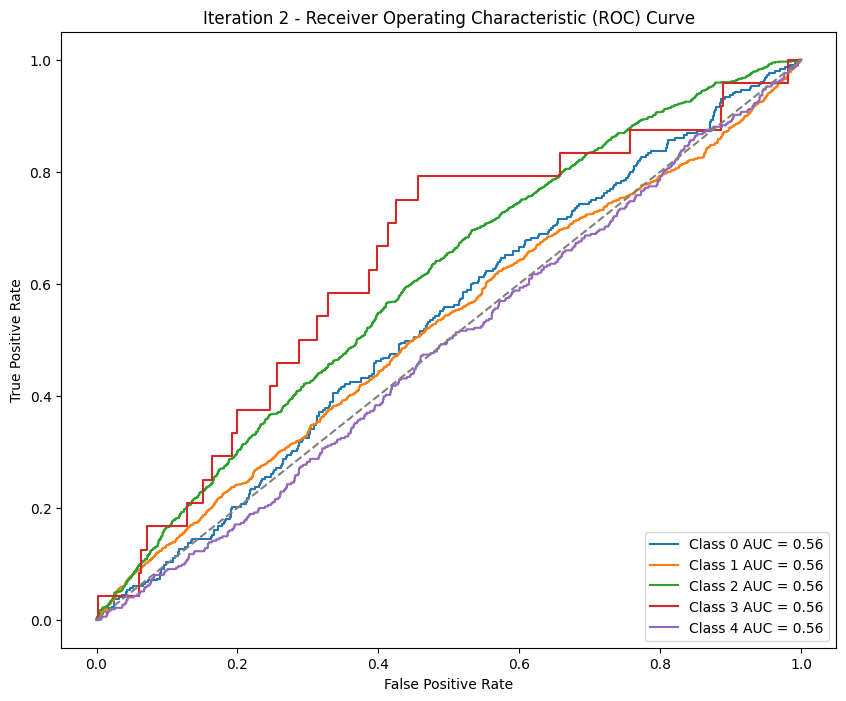

In [130]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import seaborn as sns
from tensorflow.keras import backend as K

# Function to compute and print metrics
def evaluate_metrics(y_true, y_pred, y_pred_prob, num_classes, iteration):
    print(f"Evaluation Metrics - Iteration {iteration}:\n")
    
    # Confusion Matrix
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report
    report = classification_report(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1), target_names=[f'Class {i}' for i in range(num_classes)])
    print("\nClassification Report:")
    print(report)
    
    # Accuracy Score
    accuracy = accuracy_score(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy Score: {accuracy:.2f}")
    
    # AUC Score (Multi-class)
    auc = roc_auc_score(y_true, y_pred_prob, multi_class='ovr')
    print(f"AUC Score: {auc:.2f}")
    
    # Plot AUC for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {i} AUC = {auc:.2f}')
    
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f'Iteration {iteration} - Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

# ----------------- ITERATION 1 EVALUATION -----------------

# Get model predictions for Iteration 1 (initial training phase)
y_pred_1 = model_1.predict(x_val)  # Prediction (raw output)
y_pred_prob_1 = model_1.predict(x_val)  # Probabilities for AUC computation

# Call evaluate_metrics function for Iteration 1
evaluate_metrics(y_val, y_pred_1, y_pred_prob_1, num_classes=5, iteration=1)  # Adjust num_classes as per your dataset

# ----------------- ITERATION 2 EVALUATION -----------------

# Get model predictions for Iteration 2 (fine-tuning phase)
# Assuming model_1 is now fine-tuned
y_pred_2 = model_1.predict(x_val)  # Prediction (raw output) after fine-tuning
y_pred_prob_2 = model_1.predict(x_val)  # Probabilities for AUC computation after fine-tuning

# Call evaluate_metrics function for Iteration 2
evaluate_metrics(y_val, y_pred_2, y_pred_prob_2, num_classes=5, iteration=2)  # Adjust num_classes as per your dataset


In [128]:
# ----------------- ITERATION 2: Fine-Tune (Unfreeze and Retrain) -----------------

# Unfreeze the last few layers of the EfficientNet model (fine-tuning)
for layer in base_model.layers[-30:]:  # Unfreeze the last 30 layers
    layer.trainable = True

# Recompile the model with a lower learning rate for fine-tuning
model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Fine-tune the model (Iteration 2)
history_phase2 = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    epochs=10,  # Fine-tune for additional epochs
    batch_size=32,
    callbacks=[early_stopping]
)



Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.2157 - auc_14: 0.4973 - loss: 1.8364 - val_accuracy: 0.5008 - val_auc_14: 0.5519 - val_loss: 1.5214
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.2192 - auc_14: 0.5036 - loss: 1.7700 - val_accuracy: 0.1297 - val_auc_14: 0.4978 - val_loss: 1.5221
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.2231 - auc_14: 0.4920 - loss: 1.7554 - val_accuracy: 0.1248 - val_auc_14: 0.5034 - val_loss: 1.5258
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.2089 - auc_14: 0.4925 - loss: 1.6544 - val_accuracy: 0.0808 - val_auc_14: 0.4999 - val_loss: 1.5273
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.2009 - auc_14: 0.4961 - loss: 1.6952 - val_accuracy: 0.1517 - val_auc_14: 0.5047 - val_loss: 1.5245
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.2144 - auc_14: 0.4941 - loss: 1.6875 - val_accuracy: 0.1023 - val_auc_14: 0.4834 - val_loss:

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5112 - auc_14: 0.5511 - loss: 1.5215

Train Accuracy (Iteration 2): 0.51
Train Loss (Iteration 2): 1.52
Train AUC (Iteration 2): 0.54
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4945 - auc_14: 0.5440 - loss: 1.5236
Validation Accuracy (Iteration 2): 0.50
Validation Loss (Iteration 2): 1.52
Validation AUC (Iteration 2): 0.55


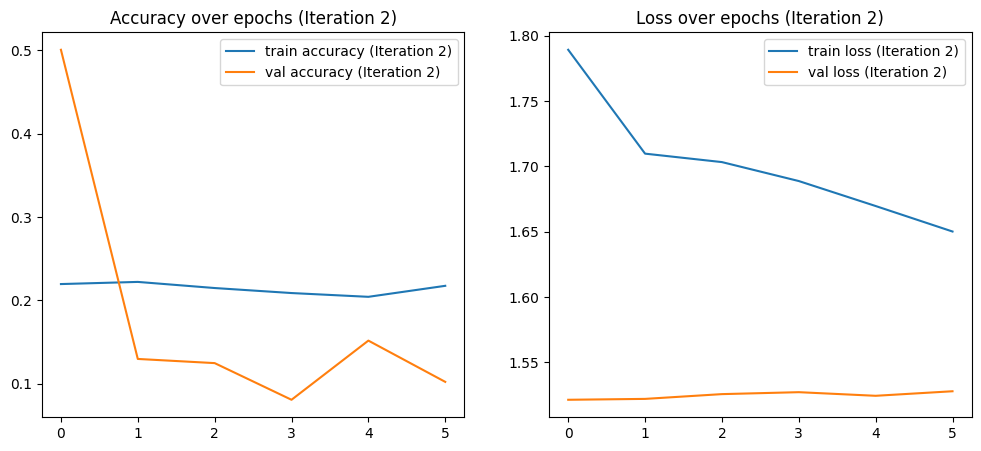

In [129]:
# ----------------- EVALUATE ITERATION 2 -----------------

# Evaluate on training data (Iteration 2)
train_loss_phase2, train_acc_phase2, train_auc_phase2 = model_1.evaluate(x_train, y_train)
print(f"\nTrain Accuracy (Iteration 2): {train_acc_phase2:.2f}\nTrain Loss (Iteration 2): {train_loss_phase2:.2f}\nTrain AUC (Iteration 2): {train_auc_phase2:.2f}")

# Evaluate on validation data (Iteration 2)
val_loss_phase2, val_acc_phase2, val_auc_phase2 = model_1.evaluate(x_val, y_val)
print(f"Validation Accuracy (Iteration 2): {val_acc_phase2:.2f}\nValidation Loss (Iteration 2): {val_loss_phase2:.2f}\nValidation AUC (Iteration 2): {val_auc_phase2:.2f}")

# ----------------- PLOTTING TRAINING CURVES FOR ITERATION 2 -----------------

# Plot the training and validation accuracy and loss curves for Iteration 2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase2.history['accuracy'], label='train accuracy (Iteration 2)')
plt.plot(history_phase2.history['val_accuracy'], label='val accuracy (Iteration 2)')
plt.title('Accuracy over epochs (Iteration 2)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase2.history['loss'], label='train loss (Iteration 2)')
plt.plot(history_phase2.history['val_loss'], label='val loss (Iteration 2)')
plt.title('Loss over epochs (Iteration 2)')
plt.legend()

plt.show()


In [115]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC
from tensorflow.keras.applications import EfficientNetB0

# Load pre-trained EfficientNet model without top layers
base_model = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model initially
base_model.trainable = False

# Input layer
input_layer = layers.Input(shape=(64, 64, 3))

# EfficientNet base model
x = base_model(input_layer)

# Global Average Pooling layer
x = layers.GlobalAveragePooling2D()(x)

# Add a few more dense layers (with ReLU and Dropout)
x = layers.Dense(128, activation='relu')(x)  # Increased the size to 128
x = layers.Dropout(0.5)(x)  # Dropout for regularization

x = layers.Dense(64, activation='relu')(x)  # Additional dense layer
x = layers.Dropout(0.3)(x)  # Dropout for regularization

# Output layer with softmax activation for multi-class classification
output_layer = layers.Dense(5, activation='softmax')(x)

# Define the model using the functional API
model_1 = models.Model(inputs=input_layer, outputs=output_layer)

# Compile the model (initial training with frozen base model layers)
model_1.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Model summary before training
model_1.summary()

# EarlyStopping callback to stop training if validation loss doesn't improve
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train only top layers first (Phase 1)
history = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    epochs=10,  # Train fewer epochs before fine-tuning
    batch_size=32,
    callbacks=[early_stopping]
)

# # ----------------- PHASE 2: UNFREEZE LAST FEW LAYERS -----------------

# # Unfreeze the last few layers of the EfficientNet model
# for layer in base_model.layers[-30:]:  # Unfreeze the last 30 layers
#     layer.trainable = True

# # Recompile the model with a lower learning rate for fine-tuning
# model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# # Fine-tune the model (Phase 2)
# history_finetune = model_1.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     class_weight=class_weights,
#     epochs=10,  # Fine-tune for additional epochs
#     batch_size=32,
#     callbacks=[early_stopping]
# )


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,120 (16.11 MB)

 Trainable params: 172,549 (674.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.1510 - auc_10: 0.4913 - loss: 1.6101 - val_accuracy: 0.0060 - val_auc_10: 0.5072 - val_loss: 1.6427
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1308 - auc_10: 0.4873 - loss: 1.6202 - val_accuracy: 0.0747 - val_auc_10: 0.5000 - val_loss: 1.6094
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.1519 - auc_10: 0.4922 - loss: 1.5864 - val_accuracy: 0.0747 - val_auc_10: 0.5000 - val_loss: 1.6083
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.2434 - auc_10: 0.4892 - loss: 1.6643 - val_accuracy: 0.5315 - val_auc_10: 0.5000 - val_loss: 1.6044
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.3834 - auc_10: 0.5013 - loss: 1.5957 - val_accuracy: 0.5315 - val_auc_10: 0.5000 - val_loss: 1.6042
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4590 - auc_10: 0.4993 - loss: 1.5964 - val_accuracy: 0.5315 - val_auc_10: 0.5000 - val_loss:

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5384 - auc_12: 0.5192 - loss: 1.5173
Train Accuracy (Phase 1): 0.54
Train Loss (Phase 1): 1.52
Train AUC (Phase 1): 0.52
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5272 - auc_12: 0.5294 - loss: 1.5179
Validation Accuracy (Phase 1): 0.53
Validation Loss (Phase 1): 1.52
Validation AUC (Phase 1): 0.53


NameError: name 'history_phase1' is not defined

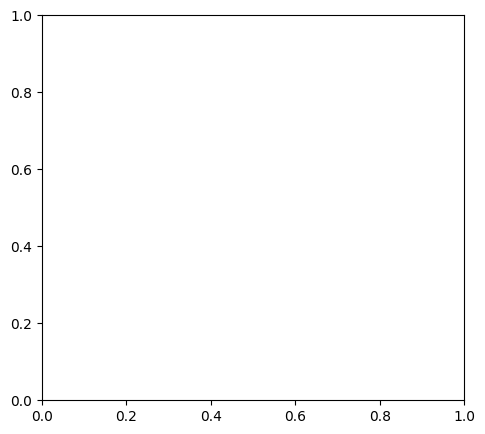

In [124]:
# Evaluate on training data
train_loss_phase1, train_acc_phase1, train_auc_phase1 = model_1.evaluate(x_train, y_train)
print(f"Train Accuracy (Phase 1): {train_acc_phase1:.2f}\nTrain Loss (Phase 1): {train_loss_phase1:.2f}\nTrain AUC (Phase 1): {train_auc_phase1:.2f}")

# Evaluate on validation data
val_loss_phase1, val_acc_phase1, val_auc_phase1 = model_1.evaluate(x_val, y_val)
print(f"Validation Accuracy (Phase 1): {val_acc_phase1:.2f}\nValidation Loss (Phase 1): {val_loss_phase1:.2f}\nValidation AUC (Phase 1): {val_auc_phase1:.2f}")

# Plot the training and validation accuracy and loss curves for Phase 1
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'], label='train accuracy (Phase 1)')
plt.plot(history_phase1.history['val_accuracy'], label='val accuracy (Phase 1)')
plt.title('Accuracy over epochs (Phase 1)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'], label='train loss (Phase 1)')
plt.plot(history_phase1.history['val_loss'], label='val loss (Phase 1)')
plt.title('Loss over epochs (Phase 1)')
plt.legend()

plt.show()

In [117]:
# # Load pretrained EfficientNet model without the top classification layers
# base_model = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))

# # Freeze base model
# base_model.trainable = False

# # Build the final model by adding custom layers on top
# model_1 = models.Sequential([
#     base_model,
#     layers.GlobalAveragePooling2D(),
#     layers.Dense(64, activation='relu'),
#     layers.Dense(5, activation='softmax')  # Adjust output units for your classes
# ])

# # Compile the model
# model_1.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# # Model Summary before training
# model_1.summary()

# from tensorflow.keras.callbacks import EarlyStopping

# # Train Model (Iteration 1)

# # Train the model with EarlyStopping
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# history = model_1.fit(
#     x_train,y_train,
#     validation_data=(x_val, y_val),
#     class_weight=class_weights,
#     epochs=20,
#     batch_size=32,
#     callbacks=[early_stopping]
# )

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,131,880 (15.76 MB)

 Trainable params: 82,309 (321.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.1599 - auc_11: 0.4851 - loss: 1.6472 - val_accuracy: 0.0747 - val_auc_11: 0.4904 - val_loss: 1.5781
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.1550 - auc_11: 0.4971 - loss: 1.6071 - val_accuracy: 0.2937 - val_auc_11: 0.4826 - val_loss: 1.5013
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.1597 - auc_11: 0.4954 - loss: 1.6161 - val_accuracy: 0.0060 - val_auc_11: 0.4997 - val_loss: 1.6233
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.0999 - auc_11: 0.4788 - loss: 1.5947 - val_accuracy: 0.0940 - val_auc_11: 0.4998 - val_loss: 1.6307
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.1132 - auc_11: 0.4921 - loss: 1.6738 - val_accuracy: 0.0747 - val_auc_11: 0.5000 - val_loss: 1.5622
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.1746 - auc_11: 0.4819 - loss: 1.6231 - val_accuracy: 0.0060 - val_auc_11: 0.5000 - val_loss:

#### Iteration 1 - Evaluation

400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2809 - auc_11: 0.4840 - loss: 1.5044
Train Accuracy: 0.28
Train Loss: 1.50
Train AUC: 0.49
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2849 - auc_11: 0.4847 - loss: 1.5065
Validation Accuracy: 0.29
Validation Loss: 1.50
Validation AUC: 0.48


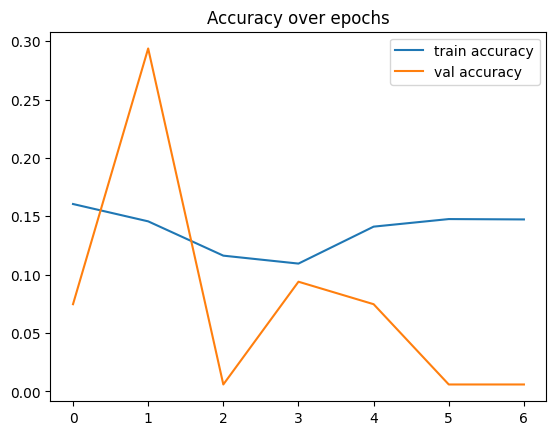

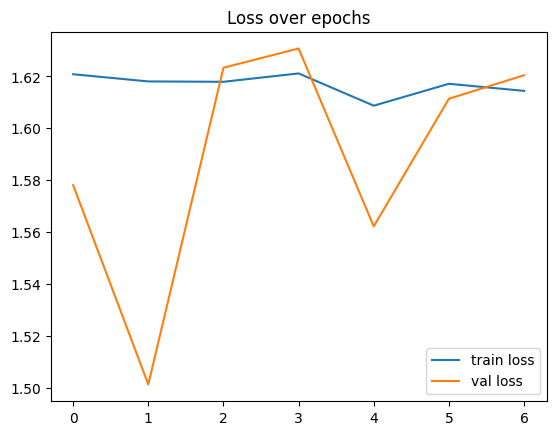

In [118]:
# Evaluate on training data
train_loss, train_acc, train_auc = model_1.evaluate(x_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}\nTrain Loss: {train_loss:.2f}\nTrain AUC: {train_auc:.2f}")

# Evaluate on validation data
val_loss, val_acc, val_auc = model_1.evaluate(x_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}\nValidation Loss: {val_loss:.2f}\nValidation AUC: {val_auc:.2f}")

# Plot the training and validation accuracy and loss curves
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step
Confusion Matrix:
 [[   0    0  299    0    0]
 [   0    0 2126    0    0]
 [   0    0 1175    0    0]
 [   0    0   24    0    0]
 [   0    0  376    0    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       299
           1       0.00      0.00      0.00      2126
           2       0.29      1.00      0.45      1175
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00       376

    accuracy                           0.29      4000
   macro avg       0.06      0.20      0.09      4000
weighted avg       0.09      0.29      0.13      4000

Accuracy: 0.2938

AUC for each class:
Class 0: AUC = 0.45
Class 1: AUC = 0.40
Class 2: AUC = 0.52
Class 3: AUC = 0.74
Class 4: AUC = 0.35




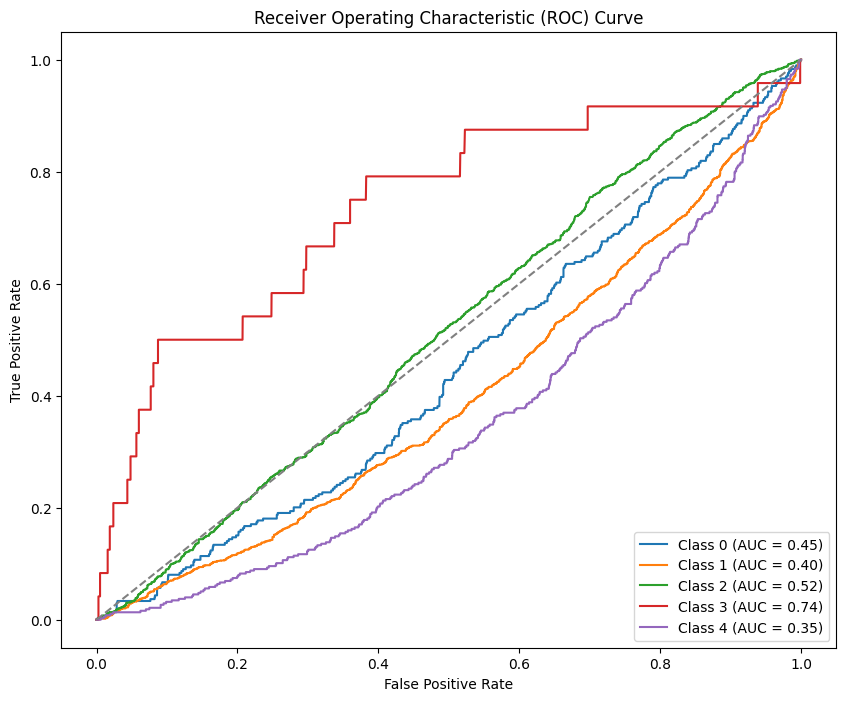

Average AUC: 0.49


0.4903865086325764

In [119]:
# Function to compute and print confusion matrix and classification report
def evaluate_model_performance(y_val, y_pred):
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), zero_division=0))

# Function to compute accuracy score
def compute_accuracy(y_val_processed, y_pred):
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy: {accuracy:.4f}\n")
    return accuracy

# Function to compute and plot ROC curve and AUC for each class
def plot_roc_curve(y_val, y_pred, n_classes=5):
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Print AUC values for each class
    print("AUC for each class:")
    for i in range(n_classes):
        print(f"Class {i}: AUC = {roc_auc[i]:.2f}")
    print("\n")

    # Plot ROC curve
    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    # Calculate and print overall average AUC score
    average_auc = np.mean(list(roc_auc.values()))
    print(f'Average AUC: {average_auc:.2f}')
    return average_auc

# Example usage
y_pred = model_1.predict(x_val)  # Predicted class probabilities for validation set

# Call functions for evaluation
evaluate_model_performance(y_val, y_pred)
compute_accuracy(y_val, y_pred)
plot_roc_curve(y_val, y_pred, n_classes=5)


### Iteration 2 - Model 1

In [120]:
# ----------------- PHASE 2: UNFREEZE LAST FEW LAYERS -----------------

# Unfreeze the last few layers of the EfficientNet model
for layer in base_model.layers[-30:]:  # Unfreeze the last 30 layers
    layer.trainable = True

# Recompile the model with a lower learning rate for fine-tuning
model_1.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Fine-tune the model (Phase 2)
history_finetune = model_1.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    epochs=10,  # Fine-tune for additional epochs
    batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.1407 - auc_12: 0.5139 - loss: 1.7518 - val_accuracy: 0.3140 - val_auc_12: 0.5262 - val_loss: 1.5676
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.1813 - auc_12: 0.4972 - loss: 1.6407 - val_accuracy: 0.0075 - val_auc_12: 0.5093 - val_loss: 1.5513
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.1868 - auc_12: 0.4961 - loss: 1.6425 - val_accuracy: 0.0075 - val_auc_12: 0.5304 - val_loss: 1.5476
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.1665 - auc_12: 0.4904 - loss: 1.7377 - val_accuracy: 0.0918 - val_auc_12: 0.5171 - val_loss: 1.5535
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.1698 - auc_12: 0.4969 - loss: 1.6619 - val_accuracy: 0.0063 - val_auc_12: 0.5341 - val_loss: 1.5653
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.2070 - auc_12: 0.4962 - loss: 1.6405 - val_accuracy: 0.0060 - val_auc_12: 0.5242 - val_loss:

In [125]:
# Evaluate on training data
train_loss_phase2, train_acc_phase2, train_auc_phase2 = model_1.evaluate(x_train, y_train)
print(f"\nTrain Accuracy (Phase 2): {train_acc_phase2:.2f}\nTrain Loss (Phase 2): {train_loss_phase2:.2f}\nTrain AUC (Phase 2): {train_auc_phase2:.2f}")

# Evaluate on validation data
val_loss_phase2, val_acc_phase2, val_auc_phase2 = model_1.evaluate(x_val, y_val)
print(f"Validation Accuracy (Phase 2): {val_acc_phase2:.2f}\nValidation Loss (Phase 2): {val_loss_phase2:.2f}\nValidation AUC (Phase 2): {val_auc_phase2:.2f}")


400/400 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5384 - auc_12: 0.5192 - loss: 1.5173

Train Accuracy (Phase 2): 0.54
Train Loss (Phase 2): 1.52
Train AUC (Phase 2): 0.52
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.5272 - auc_12: 0.5294 - loss: 1.5179
Validation Accuracy (Phase 2): 0.53
Validation Loss (Phase 2): 1.52
Validation AUC (Phase 2): 0.53


In [23]:
# Load EfficientNetB0 without the top layers (feature extractor)
base_model = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))
#efficientnetb0_notop.h5

# Freeze base model layers to use as a feature extractor
base_model.trainable = False

# Build the custom model on top of the pre-trained base model
model_1a = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Pooling layer to reduce output dimensions
    layers.Dense(128, activation='relu'),  # Custom fully connected layer
    layers.Dense(5, activation='softmax')  # Output layer for 5 classes (change for your classes)
])

# Compile the model (without fine-tuning)
model_1a.compile(optimizer=Adam(learning_rate=1e-4),  # Initial training with a higher learning rate
              loss='categorical_crossentropy',
               metrics=['accuracy', AUC(multi_label=True)])

# Model Summary before fine-tuning
model_1a.summary()

# Unfreeze some layers in the base model for fine-tuning
base_model.trainable = True
fine_tune_at = 100  # Unfreeze layers after this point

# Freeze all layers up to 'fine_tune_at'
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile the model for fine-tuning
model_1a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['AUC', 'accuracy'])

# EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss',  # Use 'val_loss' or 'val_accuracy' to monitor
                           patience=3,  # Number of epochs to wait for improvement
                           restore_best_weights=True)  # Automatically restore best weights

# ModelCheckpoint callback
checkpoint = ModelCheckpoint('best_model.weights.h5',  # Path where to save the model
                             monitor='val_loss',  # Monitor validation loss for saving
                             save_best_only=True,  # Save the best model
                             save_weights_only=True,  # Save weights only, not the full model
                             mode='min',  # Minimize validation loss
                             verbose=1)  # Print the status

# Train the model with both callbacks
history_1a = model_1a.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_data=(x_val, y_val),
                    class_weight=class_weights,
                    callbacks=[early_stop, checkpoint])


# Train the model with class weights
#history_1a = model_1a.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_val, y_val), class_weight=class_weights)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - AUC: 0.4704 - accuracy: 0.1517 - loss: 1.7214
Epoch 1: val_loss improved from inf to 2.93855, saving model to best_model.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - AUC: 0.4704 - accuracy: 0.1517 - loss: 1.7213 - val_AUC: 0.2265 - val_accuracy: 0.0940 - val_loss: 2.9386
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - AUC: 0.5141 - accuracy: 0.1998 - loss: 1.7051
Epoch 2: val_loss improved from 2.93855 to 2.11703, saving model to best_model.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - AUC: 0.5141 - accuracy: 0.1997 - loss: 1.7050 - val_AUC: 0.4484 - val_accuracy: 0.0747 - val_loss: 2.1170
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - AUC: 0.5093 - accuracy: 0.1824 - loss: 1.6793
Epoch 3: val_loss did not improve from 2.11703
400/400 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - AUC: 0.5093 - accuracy: 0.1825 - loss: 1.6792 - val_AUC: 0.3468 - val_accuracy: 0.0747 - val_loss: 2.2456
Epoch 4/10
400/400 ━━

#### Iteration 2 - Evaluation

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - AUC: 0.7134 - accuracy: 0.5384 - loss: 1.4834
Train Accuracy: 0.72
Train Loss: 1.48
Train AUC: 0.54
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - AUC: 0.7066 - accuracy: 0.5274 - loss: 1.4953
Validation Accuracy: 0.71
Validation Loss: 1.49
Validation AUC: 0.53


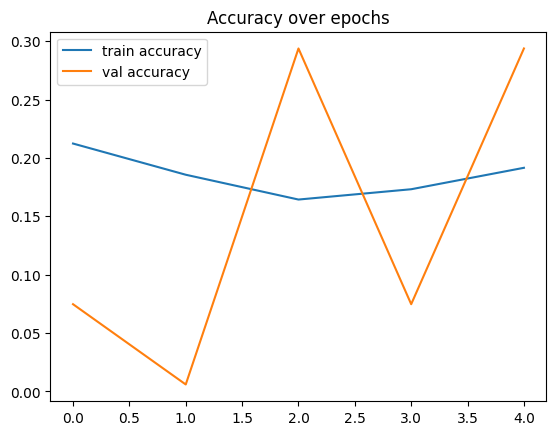

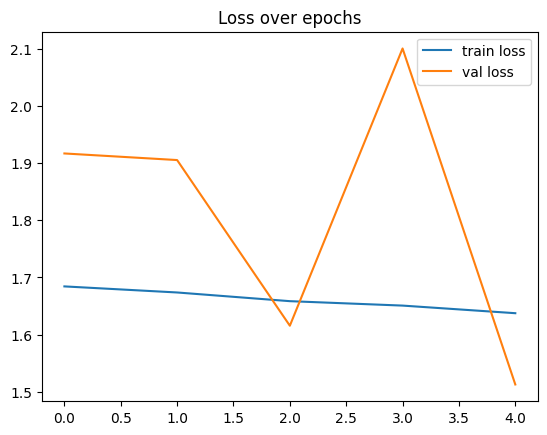

In [26]:
# Evaluate on training data
train_loss, train_acc, train_auc = model_1a.evaluate(x_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}\nTrain Loss: {train_loss:.2f}\nTrain AUC: {train_auc:.2f}")

# Evaluate on validation data
val_loss, val_acc, val_auc = model_1a.evaluate(x_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}\nValidation Loss: {val_loss:.2f}\nValidation AUC: {val_auc:.2f}")

# Plot the training and validation accuracy and loss curves
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()


400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - AUC: 0.7134 - accuracy: 0.5384 - loss: 1.4834
Train Accuracy: 0.72
Train Loss: 1.48
Train AUC: 0.54
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - AUC: 0.7066 - accuracy: 0.5274 - loss: 1.4953
Validation Accuracy: 0.71
Validation Loss: 1.49
Validation AUC: 0.53


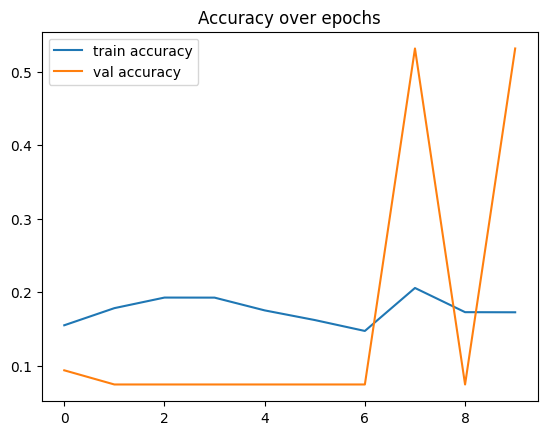

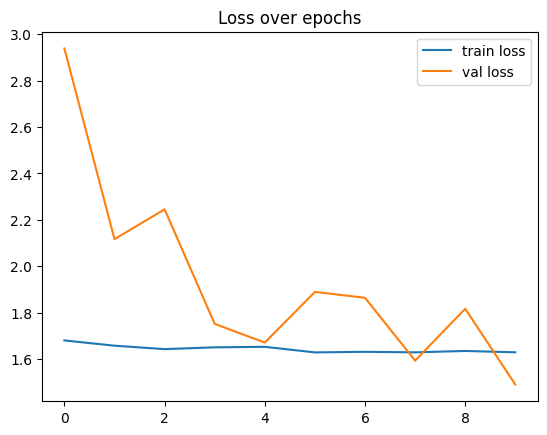

In [29]:
# Evaluate on training data
train_loss, train_acc, train_auc = model_1a.evaluate(x_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}\nTrain Loss: {train_loss:.2f}\nTrain AUC: {train_auc:.2f}")

# Evaluate on validation data
val_loss, val_acc, val_auc = model_1a.evaluate(x_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}\nValidation Loss: {val_loss:.2f}\nValidation AUC: {val_auc:.2f}")

# Plot the training and validation accuracy and loss curves
plt.plot(history_1a.history['accuracy'], label='train accuracy')
plt.plot(history_1a.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

plt.plot(history_1a.history['loss'], label='train loss')
plt.plot(history_1a.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step
Confusion Matrix:
 [[   0  299    0    0    0]
 [   0 2126    0    0    0]
 [   0 1175    0    0    0]
 [   0   24    0    0    0]
 [   0  376    0    0    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       299
           1       0.53      1.00      0.69      2126
           2       0.00      0.00      0.00      1175
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00       376

    accuracy                           0.53      4000
   macro avg       0.11      0.20      0.14      4000
weighted avg       0.28      0.53      0.37      4000

Accuracy: 0.5315

AUC for each class:
Class 0: AUC = 0.50
Class 1: AUC = 0.56
Class 2: AUC = 0.54
Class 3: AUC = 0.45
Class 4: AUC = 0.52




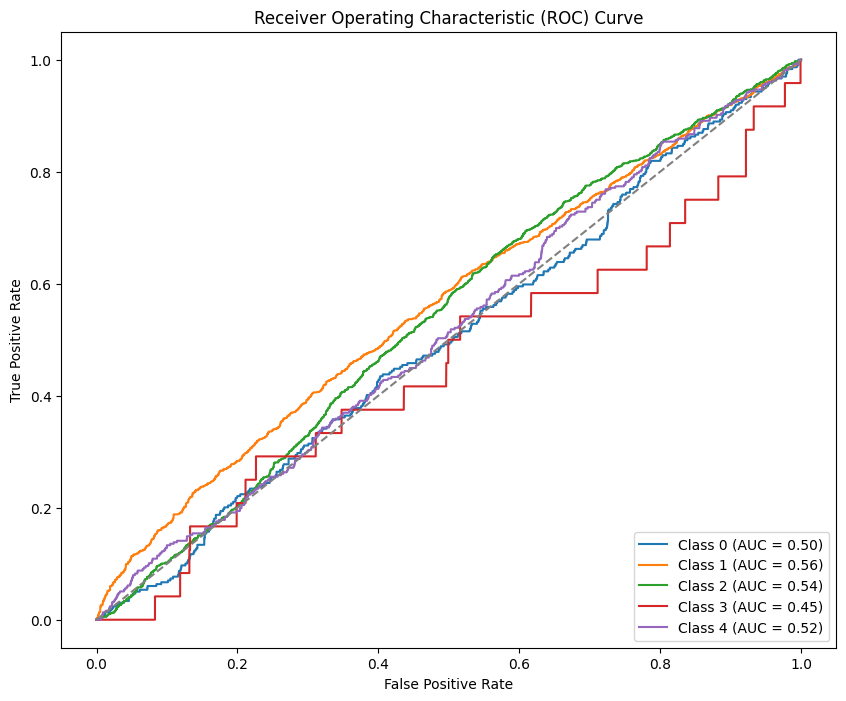

Average AUC: 0.52


0.5151105599617336

In [28]:
# Function to compute and print confusion matrix and classification report
def evaluate_model_performance(y_val, y_pred):
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), zero_division=0))

# Function to compute accuracy score
def compute_accuracy(y_val, y_pred):
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy: {accuracy:.4f}\n")
    return accuracy

# Function to compute and plot ROC curve and AUC for each class
def plot_roc_curve(y_val, y_pred, n_classes=5):
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Print AUC values for each class
    print("AUC for each class:")
    for i in range(n_classes):
        print(f"Class {i}: AUC = {roc_auc[i]:.2f}")
    print("\n")

    # Plot ROC curve
    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    # Calculate and print overall average AUC score
    average_auc = np.mean(list(roc_auc.values()))
    print(f'Average AUC: {average_auc:.2f}')
    return average_auc

# Example usage
y_pred = model_1a.predict(x_val)  # Predicted class probabilities for validation set

# Call functions for evaluation
evaluate_model_performance(y_val, y_pred)
compute_accuracy(y_val, y_pred)
plot_roc_curve(y_val, y_pred, n_classes=5)

### Model 2 - Model Building and Training (with data augumentation)

### Iteration 1 - Model 2

In [20]:
# Define ImageDataGenerator for training and validation
train_datagen = ImageDataGenerator(
    rotation_range=20,  # Random rotation
    width_shift_range=0.2,  # Random horizontal shift
    height_shift_range=0.2,  # Random vertical shift
    shear_range=0.2,  # Shearing transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'  # Fill mode for newly created pixels
)

val_datagen = ImageDataGenerator()  

# Flow data from numpy arrays for training and validation
train_data = train_datagen.flow(x_train, y_train, batch_size=32)
val_data = val_datagen.flow(x_val, y_val, batch_size=32)

In [21]:
# Build the EfficientNetB0 model without the top layer
base_model = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))

base_model.trainable = False

# Add custom layers on top
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(5, activation='softmax')(x)  # Adjust for your number of classes

model_2 = Model(inputs=base_model.input, outputs=x)
model_2.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(multi_label=True)])

# Model Summary before training
model_2.summary()

# Train the model with EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_2 = model_2.fit(
    train_data,
    validation_data=val_data,
    class_weight=class_weights,
    batch_size=32,
    epochs=20,
    callbacks=[early_stopping]
)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 64, 64, 3) │          0 │ input_layer_5[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 64, 64, 3) │          7 │ rescaling_5[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 65, 65, 3) │          0 │ normalization_5[… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 32, 32,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 32, 32,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 32, 32,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 32, 32,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 32, 32,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 32, 32,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 32, 32,    │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 32, 32,    │         64 │ block1a_project_

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


400/400 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.2179 - auc_5: 0.4909 - loss: 1.6511 - val_accuracy: 0.0940 - val_auc_5: 0.5000 - val_loss: 1.6633
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.1372 - auc_5: 0.4945 - loss: 1.6369 - val_accuracy: 0.0060 - val_auc_5: 0.5000 - val_loss: 1.6056
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0925 - auc_5: 0.4888 - loss: 1.6050 - val_accuracy: 0.2937 - val_auc_5: 0.5000 - val_loss: 1.6083
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.1380 - auc_5: 0.5010 - loss: 1.6916 - val_accuracy: 0.0060 - val_auc_5: 0.5000 - val_loss: 1.6107
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.0253 - auc_5: 0.5011 - loss: 1.6191 - val_accuracy: 0.2937 - val_auc_5: 0.5000 - val_loss: 1.6024
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0402 - auc_5: 0.4886 - loss: 1.6489 - val_accuracy: 0.5315 - val_auc_5: 0.5000 - val_loss: 1.5995
Epoch 7/20
400/

#### Iteration 1 - Evaluation

400/400 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.5384 - auc_5: 0.4990 - loss: 1.5995
Train Accuracy: 0.54
Train Loss: 1.60
Train AUC: 0.50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5274 - auc_5: 0.5000 - loss: 1.5996
Validation Accuracy: 0.53
Validation Loss: 1.60
Validation AUC: 0.50


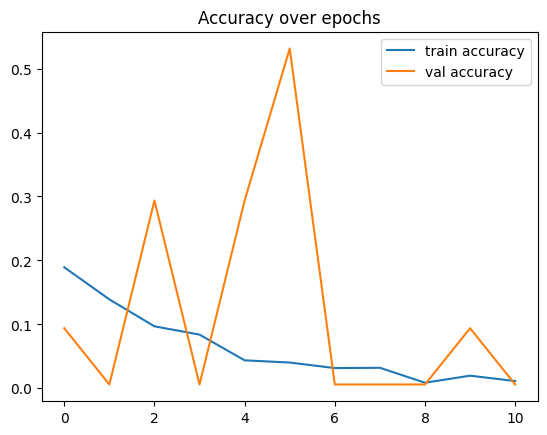

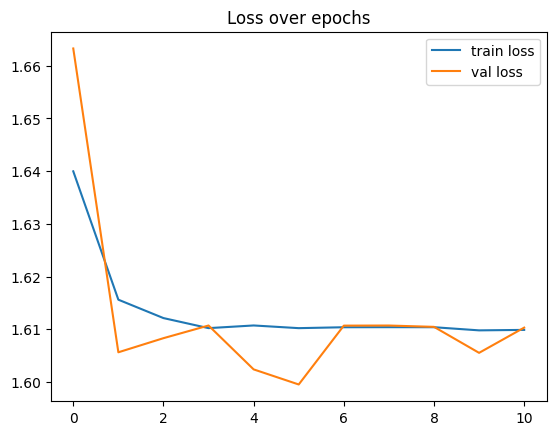

In [22]:
# Evaluate on training data
train_loss, train_acc, train_auc = model_2.evaluate(x_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}\nTrain Loss: {train_loss:.2f}\nTrain AUC: {train_auc:.2f}")

# Evaluate on validation data
val_loss, val_acc, val_auc = model_2.evaluate(x_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}\nValidation Loss: {val_loss:.2f}\nValidation AUC: {val_auc:.2f}")

# Plot the training and validation accuracy and loss curves
plt.plot(history_2.history['accuracy'], label='train accuracy')
plt.plot(history_2.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

plt.plot(history_2.history['loss'], label='train loss')
plt.plot(history_2.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
Confusion Matrix:
 [[   0  299    0    0    0]
 [   0 2126    0    0    0]
 [   0 1175    0    0    0]
 [   0   24    0    0    0]
 [   0  376    0    0    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       299
           1       0.53      1.00      0.69      2126
           2       0.00      0.00      0.00      1175
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00       376

    accuracy                           0.53      4000
   macro avg       0.11      0.20      0.14      4000
weighted avg       0.28      0.53      0.37      4000

Accuracy: 0.5315

AUC for each class:
Class 0: AUC = 0.55
Class 1: AUC = 0.50
Class 2: AUC = 0.49
Class 3: AUC = 0.50
Class 4: AUC = 0.47




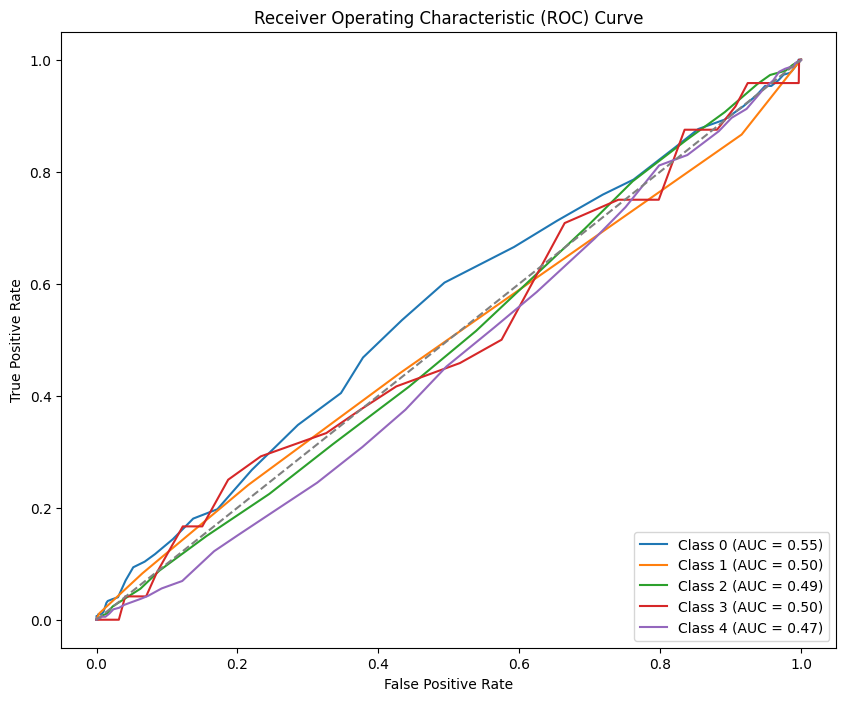

Average AUC: 0.50


0.5010693316017802

In [23]:
# Function to compute and print confusion matrix and classification report
def evaluate_model_performance(y_val, y_pred):
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), zero_division=0))

# Function to compute accuracy score
def compute_accuracy(y_val, y_pred):
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy: {accuracy:.4f}\n")
    return accuracy

# Function to compute and plot ROC curve and AUC for each class
def plot_roc_curve(y_val, y_pred, n_classes=5):
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Print AUC values for each class
    print("AUC for each class:")
    for i in range(n_classes):
        print(f"Class {i}: AUC = {roc_auc[i]:.2f}")
    print("\n")

    # Plot ROC curve
    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    # Calculate and print overall average AUC score
    average_auc = np.mean(list(roc_auc.values()))
    print(f'Average AUC: {average_auc:.2f}')
    return average_auc

# Example usage
y_pred = model_2.predict(x_val)  # Predicted class probabilities for validation set

# Call functions for evaluation
evaluate_model_performance(y_val, y_pred)
compute_accuracy(y_val, y_pred)
plot_roc_curve(y_val, y_pred, n_classes=5)

### Model 2 - Iteration 2

In [29]:
# Load EfficientNetB0 without the top layers (feature extractor)
base_model = EfficientNetB0(weights='efficientnetb0_notop.h5', include_top=False, input_shape=(64, 64, 3))
#efficientnetb0_notop.h5

# Freeze base model layers to use as a feature extractor
base_model.trainable = False

# Build the custom model on top of the pre-trained base model
model_2a = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # Pooling layer to reduce output dimensions
    layers.Dense(128, activation='relu'),  # Custom fully connected 
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')  # Output layer for 5 classes (change for your classes)
])

# Compile the model (without fine-tuning)
model_2a.compile(optimizer=Adam(learning_rate=1e-4),  # Initial training with a higher learning rate
              loss='categorical_crossentropy',
               metrics=['AUC', 'accuracy'])

# Model Summary before fine-tuning
model_2a.summary()

# Unfreeze some layers in the base model for fine-tuning
base_model.trainable = True
fine_tune_at = 150  # Unfreeze layers after this point

# Freeze all layers up to 'fine_tune_at'
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile the model for fine-tuning
model_2a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5), loss='categorical_crossentropy', metrics=['AUC', 'accuracy'])

# EarlyStopping callback
early_stop = EarlyStopping(monitor='val_loss',  # Use 'val_loss' or 'val_accuracy' to monitor
                           patience=3,  # Number of epochs to wait for improvement
                           restore_best_weights=True)  # Automatically restore best weights

# ModelCheckpoint callback
checkpoint = ModelCheckpoint('best_model.weights.h5',  # Path where to save the model
                             monitor='val_loss',  # Monitor validation loss for saving
                             save_best_only=True,  # Save the best model
                             save_weights_only=True,  # Save weights only, not the full model
                             mode='min',  # Minimize validation loss
                             verbose=1)  # Print the status

# Train the model with both callbacks
history_2a = model_2a.fit(
    train_data,
    validation_data=val_data,
    class_weight=class_weights,
    batch_size=32,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - AUC: 0.5357 - accuracy: 0.2175 - loss: 1.7941
Epoch 1: val_loss improved from inf to 1.60335, saving model to best_model.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - AUC: 0.5357 - accuracy: 0.2174 - loss: 1.7940 - val_AUC: 0.6217 - val_accuracy: 0.0747 - val_loss: 1.6034
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - AUC: 0.5236 - accuracy: 0.2217 - loss: 1.7552
Epoch 2: val_loss improved from 1.60335 to 1.54101, saving model to best_model.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - AUC: 0.5236 - accuracy: 0.2217 - loss: 1.7550 - val_AUC: 0.7735 - val_accuracy: 0.5315 - val_loss: 1.5410
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - AUC: 0.5270 - accuracy: 0.2170 - loss: 1.7019
Epoch 3: val_loss improved from 1.54101 to 1.44934, saving model to best_model.weights.h5
400/400 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - AUC: 0.5270 - accuracy: 0.2170 - loss: 1.7018 - val_AUC: 0.7907 - val_accuracy: 0.53

#### Iteration 2 - Evaluation

400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - AUC: 0.7887 - accuracy: 0.5384 - loss: 1.4503
Train Accuracy: 0.79
Train Loss: 1.45
Train AUC: 0.54
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - AUC: 0.7801 - accuracy: 0.5274 - loss: 1.4556
Validation Accuracy: 0.79
Validation Loss: 1.45
Validation AUC: 0.53


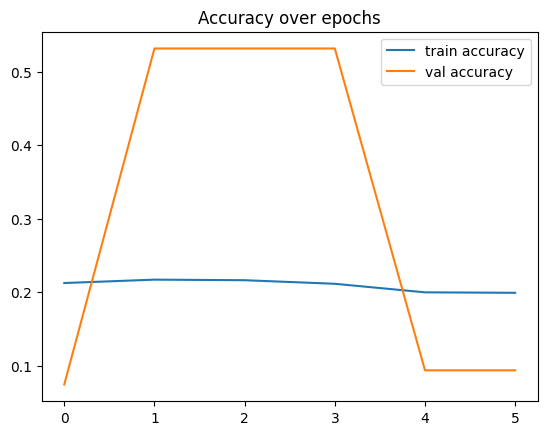

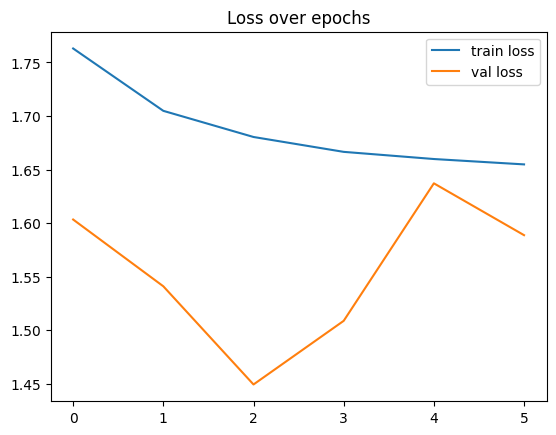

In [30]:
# Evaluate on training data
train_loss, train_acc, train_auc = model_2a.evaluate(x_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}\nTrain Loss: {train_loss:.2f}\nTrain AUC: {train_auc:.2f}")

# Evaluate on validation data
val_loss, val_acc, val_auc = model_2a.evaluate(x_val, y_val)
print(f"Validation Accuracy: {val_acc:.2f}\nValidation Loss: {val_loss:.2f}\nValidation AUC: {val_auc:.2f}")

# Plot the training and validation accuracy and loss curves
plt.plot(history_2a.history['accuracy'], label='train accuracy')
plt.plot(history_2a.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.legend()
plt.show()

plt.plot(history_2a.history['loss'], label='train loss')
plt.plot(history_2a.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.legend()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step
Confusion Matrix:
 [[   0  299    0    0    0]
 [   0 2126    0    0    0]
 [   0 1175    0    0    0]
 [   0   24    0    0    0]
 [   0  376    0    0    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       299
           1       0.53      1.00      0.69      2126
           2       0.00      0.00      0.00      1175
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00       376

    accuracy                           0.53      4000
   macro avg       0.11      0.20      0.14      4000
weighted avg       0.28      0.53      0.37      4000

Accuracy: 0.5315

AUC for each class:
Class 0: AUC = 0.55
Class 1: AUC = 0.54
Class 2: AUC = 0.51
Class 3: AUC = 0.52
Class 4: AUC = 0.50




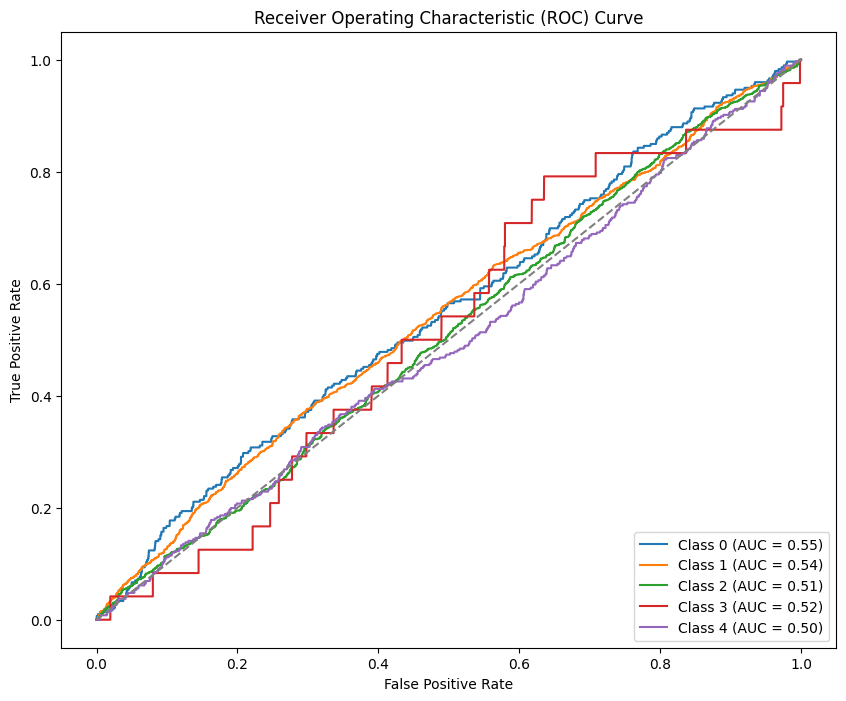

Average AUC: 0.52


0.5236556255137764

In [31]:
# Function to compute and print confusion matrix and classification report
def evaluate_model_performance(y_val, y_pred):
    cm = confusion_matrix(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1), zero_division=0))

# Function to compute accuracy score
def compute_accuracy(y_val, y_pred):
    accuracy = accuracy_score(np.argmax(y_val, axis=1), np.argmax(y_pred, axis=1))
    print(f"Accuracy: {accuracy:.4f}\n")
    return accuracy

# Function to compute and plot ROC curve and AUC for each class
def plot_roc_curve(y_val, y_pred, n_classes=5):
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Print AUC values for each class
    print("AUC for each class:")
    for i in range(n_classes):
        print(f"Class {i}: AUC = {roc_auc[i]:.2f}")
    print("\n")

    # Plot ROC curve
    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

    # Calculate and print overall average AUC score
    average_auc = np.mean(list(roc_auc.values()))
    print(f'Average AUC: {average_auc:.2f}')
    return average_auc

# Example usage
y_pred = model_2a.predict(x_val)  # Predicted class probabilities for validation set

# Call functions for evaluation
evaluate_model_performance(y_val, y_pred)
compute_accuracy(y_val, y_pred)
plot_roc_curve(y_val, y_pred, n_classes=5)

### Model Interpretability

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

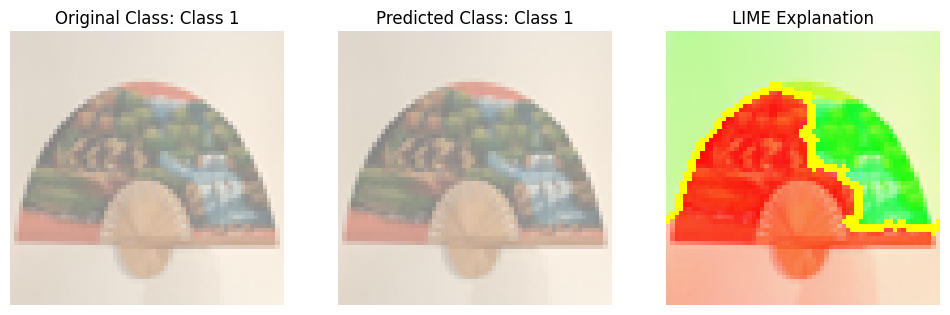

In [112]:
def explain_prediction(model, image, true_label, class_names, preprocess_fn=None):
    explainer = lime_image.LimeImageExplainer()

    # Define prediction function for LIME
    def model_predict(images):
        processed_images = np.array([preprocess_fn(img) if preprocess_fn else img for img in images])
        return model.predict(processed_images)

    # Get model prediction
    image_batch = np.expand_dims(image, axis=0)  # Add batch dimension
    prediction = model.predict(image_batch)
    predicted_class = np.argmax(prediction)

    # Generate LIME explanation
    explanation = explainer.explain_instance(image, model_predict, top_labels=1, hide_color=0, num_samples=1000)

    # Get visualization
    temp, mask = explanation.get_image_and_mask(predicted_class, positive_only=False, num_features=10, hide_rest=False)

    # Convert image back from [-1,1] to [0,255] for display
    image_display = ((image + 1) * 127.5).astype(np.uint8)  # Rescale to [0, 255]

    # Plot images
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    # Original image
    ax[0].imshow(image_display)
    ax[0].set_title(f"Original Class: {class_names[true_label]}")
    ax[0].axis("off")

    # Model prediction
    ax[1].imshow(image_display)
    ax[1].set_title(f"Predicted Class: {class_names[predicted_class]}")
    ax[1].axis("off")

    # LIME explanation
    ax[2].imshow(mark_boundaries(temp, mask))
    ax[2].set_title("LIME Explanation")
    ax[2].axis("off")

    plt.show()

sample_index = 0
x_sample = x_val[sample_index]
y_sample_label = np.argmax(y_val[sample_index])  # Convert one-hot to label if needed
class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]  # Update with actual class names

explain_prediction(model_1, x_sample, y_sample_label, class_names, preprocess_fn=preprocess_input)

### Summary Table

In [114]:
report = pd.DataFrame({
    "Task": ["Data Preprocessing", "Model Trained", "AUC Computed", "Overfitting Checked", "1st Tuning", "2nd Tuning", "Model Interpretability"],
    "Sub-task": ["Scaling & Resizing", "Training Time", "AUC & Confusion Matrix", "Handled?", "Issue Fixed?", "Issue Fixed?", "LIME"],
    "Comments": ["Done", "Done", "Done", "Done", "Improved Learning Rate", "Unfroze More Layers", "Done"]
})
print(report)


                     Task                Sub-task                Comments
0      Data Preprocessing      Scaling & Resizing                    Done
1           Model Trained           Training Time                    Done
2            AUC Computed  AUC & Confusion Matrix                    Done
3     Overfitting Checked                Handled?                    Done
4              1st Tuning            Issue Fixed?  Improved Learning Rate
5              2nd Tuning            Issue Fixed?     Unfroze More Layers
6  Model Interpretability                    LIME                    Done
